In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
car = pd.read_csv('quikr_car.csv')
car.head(2)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel


In [3]:
car['name'].unique()[0:10]

array(['Hyundai Santro Xing XO eRLX Euro III', 'Mahindra Jeep CL550 MDI',
       'Maruti Suzuki Alto 800 Vxi',
       'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
       'Maruti Suzuki Alto K10 VXi AMT', 'Skoda Fabia Classic 1.2 MPI'],
      dtype=object)

In [4]:
car['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'MARUTI', 'Force', 'Mercedes', 'Land', 'Yamaha',
       'selling', 'URJENT', 'Swift', 'Used', 'Jaguar', 'Jeep', 'tata',
       'Sale', 'very', 'Volvo', 'i', '2012', 'Well', 'all', '7', '9',
       'scratch', 'urgent', 'sell', 'TATA', 'Any', 'Tara'], dtype=object)

In [5]:
car['kms_driven'].unique()[0:10]

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms'], dtype=object)

In [6]:
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [7]:
car['Price'].unique()[0:10]

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000'],
      dtype=object)

In [8]:
car['fuel_type'].unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [9]:
car.shape

(892, 6)

In [10]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


# Data quality issues
- year has many non_year values
- year object to int
- price has Ask for price and have commas
- price object to int
- kms_driven has kms with integer
- kms_driven has nan values
- fuel_type has nan values
- keep first 3 words of name

In [11]:
backup = car.copy()

In [12]:
car = car[car['year'].str.isnumeric()]

In [13]:
car['year'] = car['year'].astype(int)

In [14]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


In [15]:
car['Price'].head(5)

0           80,000
1         4,25,000
2    Ask For Price
3         3,25,000
4         5,75,000
Name: Price, dtype: object

In [16]:
car = car[car['Price'] != "Ask For Price"]

In [17]:
car.shape

(819, 6)

In [18]:
# car['Price'].apply(lambda x: x.replace(',','')).astype(int)
car['Price'] = car['Price'].str.replace(',','').astype(int)

In [19]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [20]:
car['kms_driven'] = car['kms_driven'].str.replace(',','').apply(lambda x: x.split(' ')[0])

In [21]:
car.shape

(819, 6)

In [22]:
car = car[car['kms_driven'].str.isnumeric()]

In [23]:
car['kms_driven'] = car['kms_driven'].astype(int)

In [24]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [25]:
car.dropna(inplace=True)

In [26]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.6+ KB


In [27]:
car['name'].head()

0      Hyundai Santro Xing XO eRLX Euro III
1                   Mahindra Jeep CL550 MDI
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT
4          Ford EcoSport Titanium 1.5L TDCi
6                                 Ford Figo
Name: name, dtype: object

In [28]:
def transform_name(txt):
    words = txt.split(' ')[0:3]
    return ' '.join(words)

In [29]:
car['name'] = car['name'].apply(transform_name)

In [30]:
car['name'].head()

0       Hyundai Santro Xing
1       Mahindra Jeep CL550
3         Hyundai Grand i10
4    Ford EcoSport Titanium
6                 Ford Figo
Name: name, dtype: object

In [31]:
car.reset_index(drop=True,inplace=True)

In [32]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [33]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


In [34]:
car.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


<Axes: ylabel='Price'>

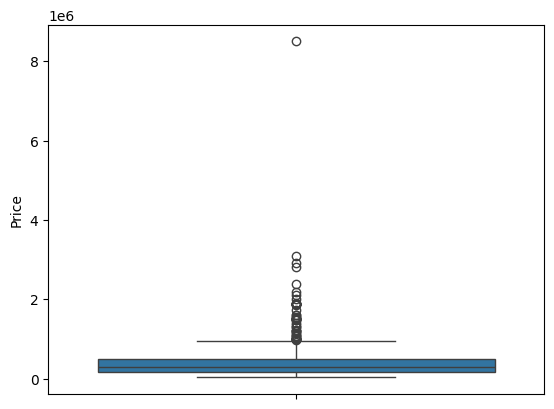

In [35]:
sns.boxplot(car['Price'])

In [36]:
car = car[car['Price']<3200000]

In [37]:
car.reset_index(drop=True,inplace=True)

In [38]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [80]:
car.to_csv('cleaned_car.csv')

In [39]:
X = car.drop('Price',axis=1)
y = car['Price']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import make_pipeline

In [138]:
# ohe = OneHotEncoder()
# ohe.fit(X[['name','company','fuel_type']])

# column_trans = make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
#                                       remainder='passthrough')

# lr = LinearRegression()

# pipe = make_pipeline(column_trans,lr)

# pipe.fit(X_train,y_train)

In [42]:
# one hot encoding
trf1 = ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[0,1,4])
],remainder='passthrough')

In [43]:
trf2 = LinearRegression()

In [44]:
pipe = make_pipeline(trf1,trf2)

In [45]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
y_pred = pipe.predict(X_test)
r2_score(y_test,y_pred)

0.6032275194059629

In [50]:
# using this function we can find the random state at which the accuracy is maximum
def func(num):
    max_score = 0
    rs = 1
    for i in range(num):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        pipe.fit(X_train,y_train)
        y_pred = pipe.predict(X_test)
        score = r2_score(y_test,y_pred)
        if score > max_score:
            max_score = score
            rs = i
    return max_score,rs
    

In [52]:
func(1000)

(0.871554431465233, 516)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=516)
# trf1 = ColumnTransformer([
#     ('ohe',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[0,1,4])
# ],remainder='passthrough')
# trf2 = LinearRegression()
pipe = make_pipeline(trf1,trf2)
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

In [54]:
r2_score(y_test,y_pred)

0.871554431465233

In [55]:
import pickle

In [65]:
with open('LRmodel.pkl','wb') as f:
    pickle.dump(pipe,f)

In [57]:
pipe.predict(pd.DataFrame([['Maruti Suzuki Swift','Maruti',2019,1000,'Diesel']],
                          columns=['name','company','year','kms_driven','fuel_type']))

array([444476.16749144])

In [58]:
df = pd.read_csv('cleaned_car.csv')

In [59]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [60]:
df['fuel_type'].unique()

array(['Petrol', 'Diesel', 'LPG'], dtype=object)

In [64]:
inputed_data = pd.DataFrame([{
        "name": 'Maruti Suzuki Swift',
        "company": 'Maruti',
        "year": 2019,
        "kms_driven": 1000,
        "fuel_type": 'Diesel'
    }])

pipe.predict(inputed_data)

array([444476.16749144])